# Data set 1 feature

In [ ]:
import numpy as np

x = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19]
y = [5.2,7.4,10.3,12.3,15.0,17.1,20.1,22.7,24.7,27.9,29.8,32.5,35.3,37.4,40.2,42.2,45.1,47.7,49.6,52.5]

x = np.array(x)
y = np.array(y)


data_set = np.column_stack((x, y))

# Añadir columna de unos al inicio
columna_unos = np.ones((data_set.shape[0], 1), dtype=int)
data_set = np.hstack((columna_unos, data_set))

n = data_set.shape[1] - 1  # excluye columna y
m = data_set.shape[0]      # número de muestras


theta = np.zeros(n)
alfa = 0.01  # learning rate

In [ ]:
def hypothesis(data_set, theta, i):
  return np.dot(theta, data_set[i, :-1].T)

In [ ]:
def gradient_descent(theta, alfa, n, m, data_set):
    theta = theta.copy()
    for j in range(n):
        suma = 0
        for i in range(m):
            error = hypothesis(data_set, theta, i) - data_set[i, -1]
            suma += error * data_set[i, j]
        theta[j] -= (alfa / m) * suma
    return theta

In [ ]:
def cost(theta, data_set, m):
    total = 0
    for i in range(m):
        error = hypothesis(data_set, theta, i) - data_set[i, -1]
        total += error**2
    return total / (2*m)

In [ ]:

cost_history = []
for _ in range(10000):
    theta = gradient_descent(theta, alfa, n, m, data_set)
    cost_history.append(cost(theta, data_set, m))

# -----------------------------
# 7. Resultados finales
# -----------------------------
print("Theta final:", theta)
print("Coste final:", cost_history[-1])

Theta final: [5.03571429 2.4962406 ]
Coste final: 0.027765037593984954


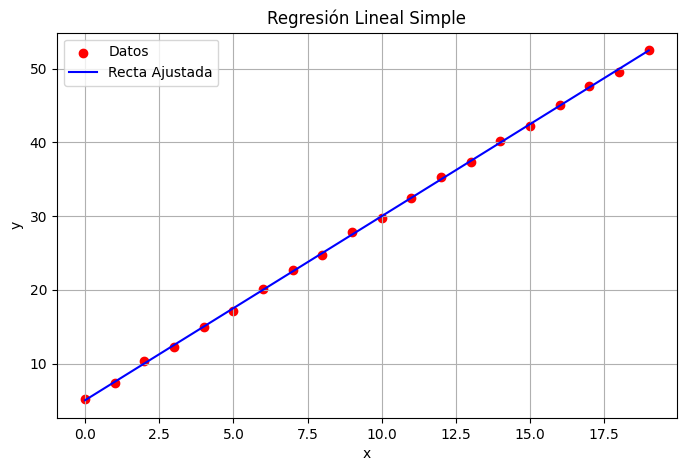

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='red', label='Datos')

# Línea ajustada
y_pred = theta[0] + theta[1]*x
plt.plot(x, y_pred, color='blue', label='Recta Ajustada')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Lineal Simple')
plt.legend()
plt.grid(True)
plt.show()

# Normal equation

In [ ]:
X = data_set[:, :-1]
Y = data_set[:, -1]
theta = np.linalg.inv(X.T @ X) @ X.T @ Y
theta

array([5.03571429, 2.4962406 ])

# Data set with 2 features

Theta final: [2.30359016 0.67413488 1.16931002]


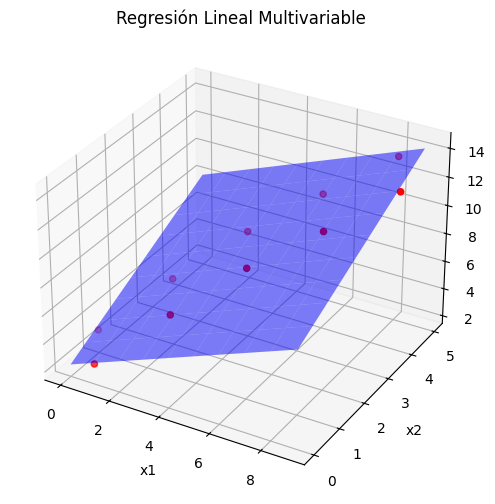

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# -----------------------------
# Datos de ejemplo
# -----------------------------
x1 = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
x2 = np.array([1, 0, 2, 1, 3, 2, 4, 3, 5, 4])
y  = np.array([3.1, 2.9, 6.2, 5.8, 9.0, 8.5, 11.1, 10.5, 13.2, 12.7])

# Dataset con columna de unos
data_set = np.column_stack((x1, x2, y))
columna_unos = np.ones((data_set.shape[0], 1), dtype=int)
data_set = np.hstack((columna_unos, data_set))

# Inicializar theta
n = data_set.shape[1] - 1
m = data_set.shape[0]
theta = np.zeros(n)
alfa = 0.01

# Función hipótesis
def h(data_set, theta, i):
    return np.dot(theta, data_set[i, :-1].T)

# Gradiente descendente
def gradient_descent(theta, alfa, n, m, data_set):
    theta = theta.copy()
    for j in range(n):
        suma = 0
        for i in range(m):
            error = h(data_set, theta, i) - data_set[i, -1]
            suma += error * data_set[i, j]
        theta[j] -= (alfa / m) * suma
    return theta

# Entrenamiento
for _ in range(1000):
    theta = gradient_descent(theta, alfa, n, m, data_set)

print("Theta final:", theta)

# -----------------------------
# Gráfico 3D
# -----------------------------
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Puntos de datos
ax.scatter(x1, x2, y, color='red', label='Datos')

# Crear malla para el plano ajustado
X1, X2 = np.meshgrid(np.linspace(min(x1), max(x1), 10),
                     np.linspace(min(x2), max(x2), 10))
Y = theta[0] + theta[1]*X1 + theta[2]*X2

# Plano de regresión
ax.plot_surface(X1, X2, Y, color='blue', alpha=0.5, label='Plano Ajustado')

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('Regresión Lineal Multivariable')
plt.show()


# Normal equation

In [ ]:
X = data_set[:, :-1]
Y = data_set[:, -1]
theta = np.linalg.inv(X.T @ X) @ X.T @ Y
theta

array([2.46333333, 0.67666667, 1.11666667])